In [1]:
import sys
import os
import warnings

sys.path.append(os.path.abspath("../scripts"))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, 
    precision_score, recall_score
)

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

from data_loader import get_openml_data
from data_preprocessing import create_preprocessing_pipeline, preprocess_for_nn
from boosting_models import run_lr_tuning, run_catboost_tuning, run_lgbm_tuning
from deep_model import TabularDataset, TABMLP, train, evaluate

warnings.filterwarnings("ignore")

## Датасет [Bank](https://www.openml.org/search?type=data&id=1461&sort=runs&status=active)

In [2]:
dataset_id = 1461
X_train, X_valid, X_test, y_train, y_valid, y_test, categorical_indicator, attribute_names = get_openml_data(dataset_id)

In [3]:
column_transformer, categorical_features, numerical_features = create_preprocessing_pipeline(attribute_names, categorical_indicator)

In [4]:
model_lr = run_lr_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lr = model_lr.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lr.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_lr))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lr))
print("Precision = %.4f" % precision_score(y_test, y_pred_lr))
print("Recall = %.4f" % recall_score(y_test, y_pred_lr))

[I 2025-04-14 18:55:38,292] A new study created in memory with name: logistic_regression_optimization
[I 2025-04-14 18:55:38,393] Trial 0 finished with value: 0.8637615827698473 and parameters: {'penalty': 'l2', 'C': 1e-05}. Best is trial 0 with value: 0.8637615827698473.
[I 2025-04-14 18:55:38,530] Trial 1 finished with value: 0.9001371492739894 and parameters: {'penalty': 'l1', 'C': 100}. Best is trial 1 with value: 0.9001371492739894.
[I 2025-04-14 18:55:38,615] Trial 2 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 0.0001}. Best is trial 1 with value: 0.9001371492739894.
[I 2025-04-14 18:55:39,472] Trial 3 finished with value: 0.9009448008495017 and parameters: {'penalty': 'l1', 'C': 0.1}. Best is trial 3 with value: 0.9009448008495017.
[I 2025-04-14 18:55:39,676] Trial 4 finished with value: 0.9001878050293116 and parameters: {'penalty': 'l2', 'C': 100}. Best is trial 3 with value: 0.9009448008495017.
[I 2025-04-14 18:55:39,790] Trial 5 finished with value: 0.8637

ROC-AUC = 0.9141
F1 = 0.4419
Accuracy = 0.9011
Precision = 0.6507
Recall = 0.3346


In [5]:
model_cb = run_catboost_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_cb = model_cb.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_cb.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_cb))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_cb))
print("Precision = %.4f" % precision_score(y_test, y_pred_cb))
print("Recall = %.4f" % recall_score(y_test, y_pred_cb))

[I 2025-04-14 18:55:53,124] A new study created in memory with name: catboost_optimization
[I 2025-04-14 18:56:08,572] Trial 0 finished with value: 0.9086719339183836 and parameters: {'depth': 10, 'learning_rate': 0.3, 'l2_leaf_reg': 0.01}. Best is trial 0 with value: 0.9086719339183836.
[I 2025-04-14 18:56:11,635] Trial 1 finished with value: 0.9264144672837198 and parameters: {'depth': 2, 'learning_rate': 0.03, 'l2_leaf_reg': 0.1}. Best is trial 1 with value: 0.9264144672837198.
[I 2025-04-14 18:56:29,363] Trial 2 finished with value: 0.9319376015778084 and parameters: {'depth': 10, 'learning_rate': 0.03, 'l2_leaf_reg': 1.0}. Best is trial 2 with value: 0.9319376015778084.
[I 2025-04-14 18:56:34,839] Trial 3 finished with value: 0.9358693403437109 and parameters: {'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 1.0}. Best is trial 3 with value: 0.9358693403437109.
[I 2025-04-14 18:56:42,855] Trial 4 finished with value: 0.9352813548473533 and parameters: {'depth': 8, 'learning_rate

ROC-AUC = 0.9408
F1 = 0.5751
Accuracy = 0.9124
Precision = 0.6650
Recall = 0.5066


In [6]:
model_lgbm = run_lgbm_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lgbm = model_lgbm.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lgbm.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_lgbm))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lgbm))
print("Precision = %.4f" % precision_score(y_test, y_pred_lgbm))
print("Recall = %.4f" % recall_score(y_test, y_pred_lgbm))

[I 2025-04-14 18:58:35,092] A new study created in memory with name: lightgbm_optimization
[I 2025-04-14 18:58:39,700] Trial 0 finished with value: 0.9261893568944138 and parameters: {'num_leaves': 64, 'reg_alpha': 0.0001, 'reg_lambda': 0.0001, 'learning_rate': 0.1}. Best is trial 0 with value: 0.9261893568944138.
[I 2025-04-14 18:59:28,736] Trial 1 finished with value: 0.9281583034961466 and parameters: {'num_leaves': 1024, 'reg_alpha': 1e-05, 'reg_lambda': 0.1, 'learning_rate': 0.01}. Best is trial 1 with value: 0.9281583034961466.
[I 2025-04-14 18:59:31,693] Trial 2 finished with value: 0.9338156518709252 and parameters: {'num_leaves': 32, 'reg_alpha': 1e-08, 'reg_lambda': 1e-05, 'learning_rate': 0.01}. Best is trial 2 with value: 0.9338156518709252.
[I 2025-04-14 19:00:07,868] Trial 3 finished with value: 0.9256970018894122 and parameters: {'num_leaves': 4096, 'reg_alpha': 1e-08, 'reg_lambda': 0.01, 'learning_rate': 0.1}. Best is trial 2 with value: 0.9338156518709252.
[I 2025-04-1

ROC-AUC = 0.9418
F1 = 0.5768
Accuracy = 0.9111
Precision = 0.6508
Recall = 0.5180


In [7]:
X_train, X_valid, X_test = preprocess_for_nn(X_train, X_valid, X_test, categorical_features, numerical_features)

In [8]:
trainset = TabularDataset(X_train, y_train, categorical_features)
valset = TabularDataset(X_valid, y_valid, categorical_features)
testset  = TabularDataset(X_test, y_test, categorical_features)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [9]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


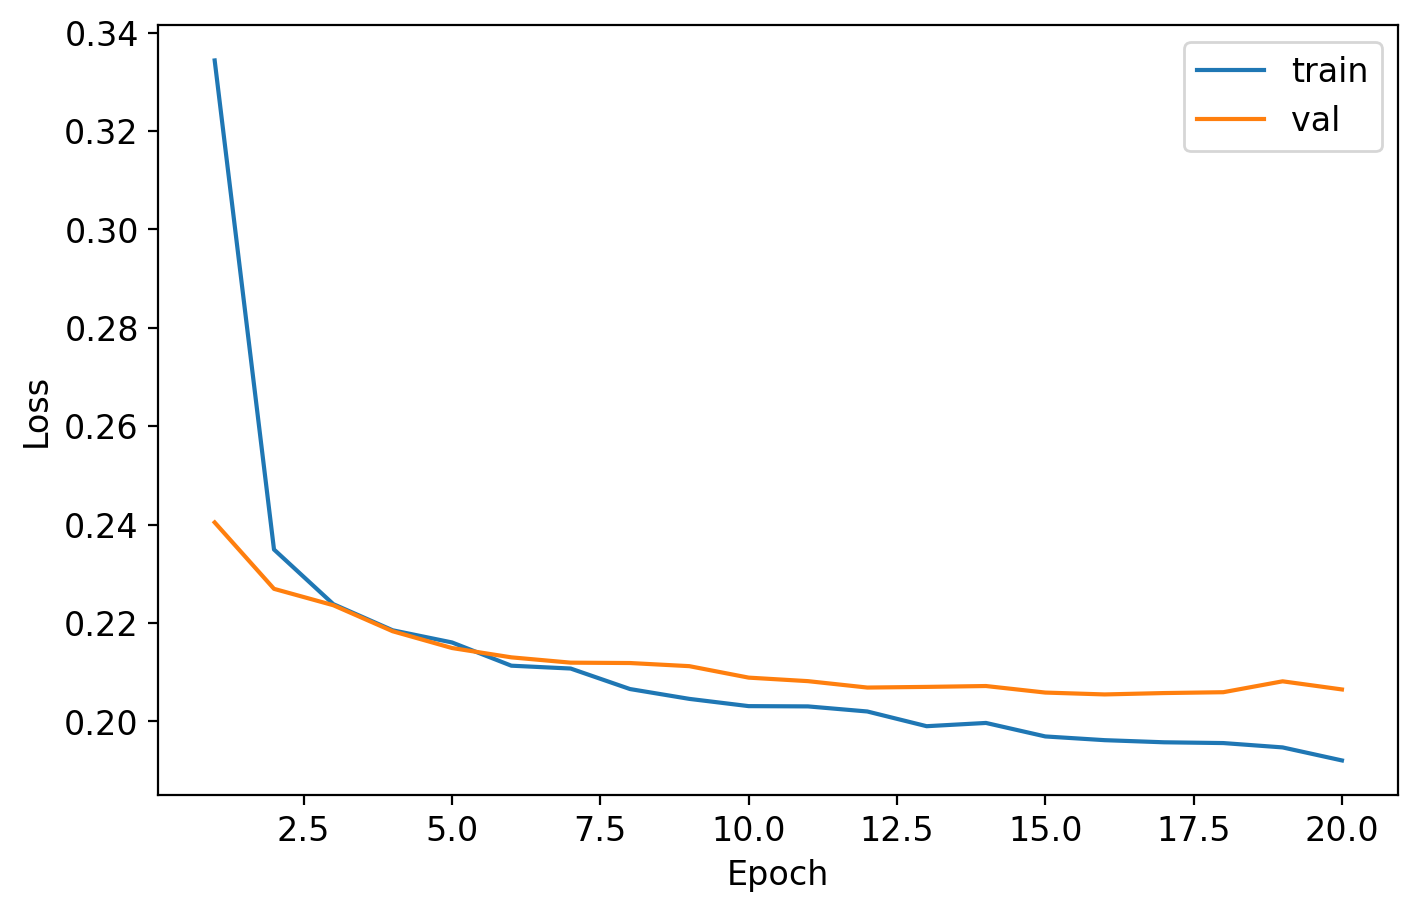

Epoch 20: train loss = 0.1920; valid loss = 0.2065


In [11]:
net = TABMLP(len(numerical_features), emb_dims).to(device)
optimizer = optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train(net, optimizer, 20, train_loader, val_loader, criterion, device)

In [12]:
y_true, y_prob, y_pred = evaluate(net, test_loader, device)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, y_prob))
print("F1 = %.4f" % f1_score(y_test, y_pred))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred))
print("Precision = %.4f" % precision_score(y_test, y_pred))
print("Recall = %.4f" % recall_score(y_test, y_pred))

ROC-AUC = 0.9331
F1 = 0.5821
Accuracy = 0.9060
Precision = 0.6066
Recall = 0.5595
